# Stock Market Analysis (NSE Sectors)

This project analyzes 1 year of stock data across Banking, IT, and Energy sectors.

Includes:
- Data cleaning
- Statistical analysis
- Technical indicators
- Correlation & sector insights
- Interactive visualizations
- Excel reporting

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import fetch_data, reshape_data
from src.quality_checks import audit_data, clean_data
from src.analysis import (
    load_data,
    calculate_returns,
    compute_statistics,
    analyze_result,
    plot_volatility,
    plot_sharpe_ratio,
    apply_indicator,
    validate_indicators,
    calculate_correlation,
    plot_correlation_heatmap,
    assign_sectors,
    compute_sector_metrics,
    top_correlations
)
from src.visualization import (
    candlestick_with_volume_graph,
    normalised_prices_graph,
    risk_return_graph
)
from src.report import excel_report
from src.config import OUTPUT_FILE

## Data Collection

Fetch 1 year OHLCV data for selected NSE stocks.

In [3]:
df_raw = fetch_data()
df = reshape_data(df_raw)

df.head()

Price,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2025-04-01,901.000000,904.950012,882.674988,883.924988,872.136353,28511006,HDFCBANK.NS
1,2025-04-02,885.349976,899.599976,885.349976,898.450012,886.467651,11573564,HDFCBANK.NS
2,2025-04-03,890.549988,902.000000,888.500000,897.424988,885.456299,11250038,HDFCBANK.NS
3,2025-04-04,906.500000,920.974976,905.549988,908.650024,896.531677,33540454,HDFCBANK.NS
4,2025-04-07,881.400024,889.924988,869.099976,878.849976,867.128967,37995450,HDFCBANK.NS


## Data Cleaning & Quality Checks

In [4]:
audit_data(df)

df = clean_data(df)

df.head()


--- Missing Values ---
Price
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

Duplicate Rows: 0

Zero volume rows: 8

=== DATA QUALITY REPORT ===

Rows fetched: 1976
Rows dropped: 8

Percent Missing Per Column:

Price
Date         0.0
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
Ticker       0.0
dtype: float64


Price,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Gap_Days,Gap_Flag
0,2025-04-01,901.00,904.95,882.67,883.92,872.14,28511006,HDFCBANK.NS,NaN,False
1,2025-04-02,885.35,899.60,885.35,898.45,886.47,11573564,HDFCBANK.NS,1.0,False
2,2025-04-03,890.55,902.00,888.50,897.42,885.46,11250038,HDFCBANK.NS,1.0,False
3,2025-04-04,906.50,920.97,905.55,908.65,896.53,33540454,HDFCBANK.NS,1.0,False
4,2025-04-07,881.40,889.92,869.10,878.85,867.13,37995450,HDFCBANK.NS,3.0,False


## Returns Calculation

In [5]:
df = calculate_returns(df)

df.head()

Price,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Gap_Days,Gap_Flag,Return
0,2025-04-01,901.00,904.95,882.67,883.92,872.14,28511006,HDFCBANK.NS,NaN,False,NaN
1,2025-04-02,885.35,899.60,885.35,898.45,886.47,11573564,HDFCBANK.NS,1.0,False,1.64
2,2025-04-03,890.55,902.00,888.50,897.42,885.46,11250038,HDFCBANK.NS,1.0,False,-0.11
3,2025-04-04,906.50,920.97,905.55,908.65,896.53,33540454,HDFCBANK.NS,1.0,False,1.25
4,2025-04-07,881.40,889.92,869.10,878.85,867.13,37995450,HDFCBANK.NS,3.0,False,-3.28


## Descriptive Statistics

In [6]:
stats_df = compute_statistics(df)

stats_df

,Mean_Return,Std_Dev,Skewness,Kurtosis,Annualized_Volatility,Sharpe_Ratio
Ticker,,,,,,
HDFCBANK.NS,-0.07,1.13,-0.51,3.30,17.94,-0.06
ICICIBANK.NS,-0.03,1.13,0.13,1.88,17.94,-0.03
INFY.NS,-0.07,1.63,0.30,4.48,25.88,-0.04
ONGC.NS,0.07,1.51,0.23,5.88,23.97,0.05
RELIANCE.NS,0.04,1.29,0.10,2.40,20.48,0.03
SBIN.NS,0.11,1.34,0.30,4.54,21.27,0.08
TCS.NS,-0.16,1.35,-0.63,4.25,21.43,-0.12
WIPRO.NS,-0.12,1.56,-0.68,3.79,24.76,-0.08


## Performance Insights

In [7]:
analyze_result(stats_df)


---Analysis---
Most Volatile Stock: INFY.NS
Best Sharpe Ratio: SBIN.NS


## Risk Metrics Visualization

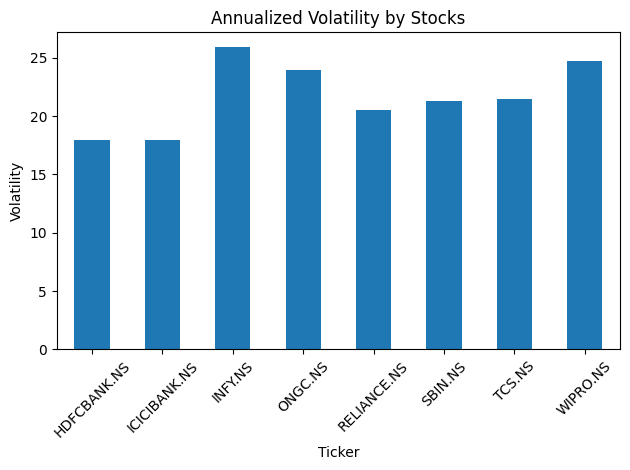

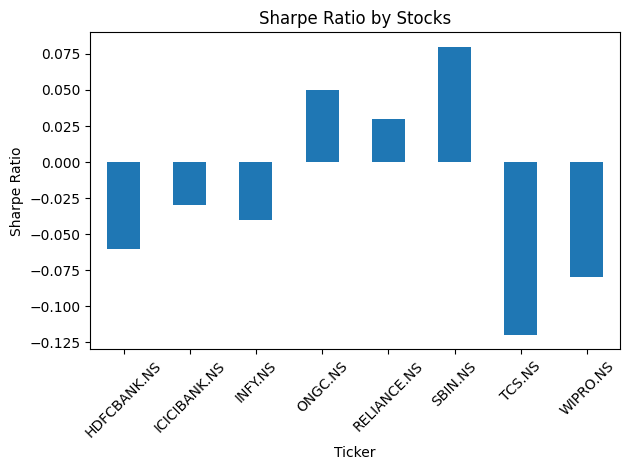

In [8]:
import os
os.chdir("..")

plot_volatility(stats_df)
plot_sharpe_ratio(stats_df)

## Technical Indicators (SMA, RSI, Bollinger Bands)

In [9]:
df = apply_indicator(df)

validate_indicators(df)

df.head()


--- Indicator Validation ---
RSI Min: 0.0
RSI Max: 100.0
RSI is below 30, indicating oversold condition
RSI is above 70, indicating overbought condition


Price,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Gap_Days,Gap_Flag,Return,SMA_20,SMA_50,SMA_200,RSI,Bollinger_Bands_Upper,Bollinger_Bands_Lower
0,HDFCBANK.NS,2025-04-01,901.00,904.95,882.67,883.92,872.14,28511006,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HDFCBANK.NS,2025-04-02,885.35,899.60,885.35,898.45,886.47,11573564,1.0,False,1.64,NaN,NaN,NaN,100.00,NaN,NaN
2,HDFCBANK.NS,2025-04-03,890.55,902.00,888.50,897.42,885.46,11250038,1.0,False,-0.11,NaN,NaN,NaN,99.46,NaN,NaN
3,HDFCBANK.NS,2025-04-04,906.50,920.97,905.55,908.65,896.53,33540454,1.0,False,1.25,NaN,NaN,NaN,99.49,NaN,NaN
4,HDFCBANK.NS,2025-04-07,881.40,889.92,869.10,878.85,867.13,37995450,3.0,False,-3.28,NaN,NaN,NaN,84.96,NaN,NaN


## Correlation Analysis

In [10]:
corr_matrix = calculate_correlation(df)

corr_matrix

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ONGC.NS,RELIANCE.NS,SBIN.NS,TCS.NS,WIPRO.NS
Ticker,,,,,,,,
HDFCBANK.NS,1.000000,0.615933,0.257635,0.112357,0.427205,0.431373,0.233506,0.203246
ICICIBANK.NS,0.615933,1.000000,0.224511,0.181099,0.260367,0.304553,0.205617,0.163861
INFY.NS,0.257635,0.224511,1.000000,0.195454,0.290447,0.174660,0.767199,0.693449
ONGC.NS,0.112357,0.181099,0.195454,1.000000,0.204813,0.258196,0.206805,0.291969
RELIANCE.NS,0.427205,0.260367,0.290447,0.204813,1.000000,0.368744,0.285066,0.301096
SBIN.NS,0.431373,0.304553,0.174660,0.258196,0.368744,1.000000,0.177060,0.154508
TCS.NS,0.233506,0.205617,0.767199,0.206805,0.285066,0.177060,1.000000,0.668439
WIPRO.NS,0.203246,0.163861,0.693449,0.291969,0.301096,0.154508,0.668439,1.000000


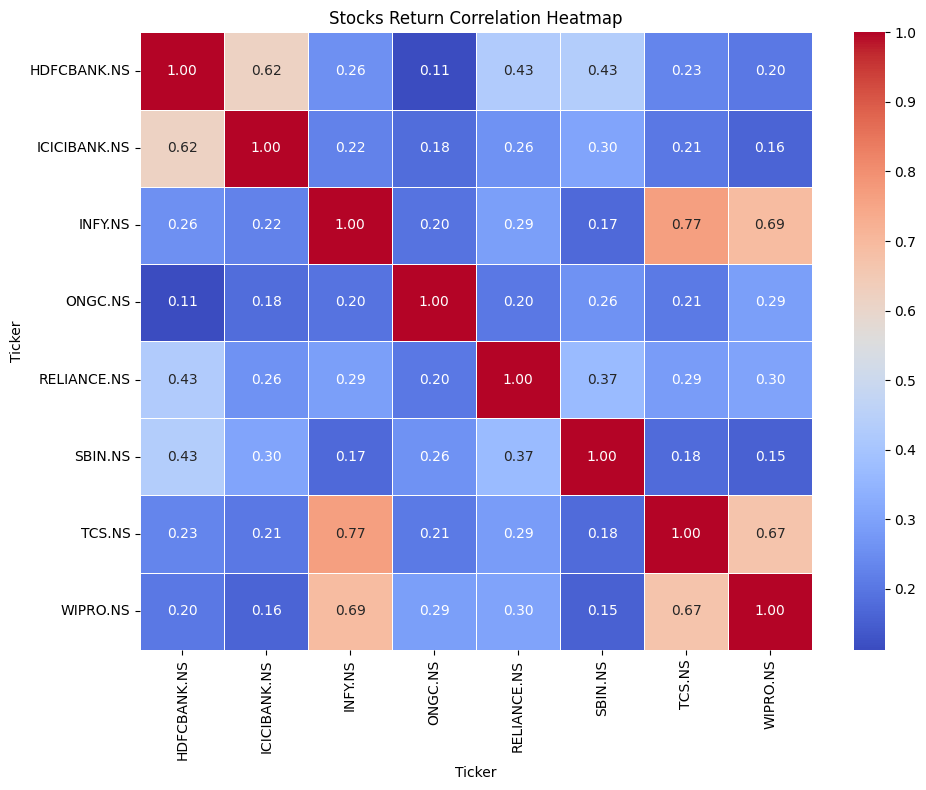

In [11]:
plot_correlation_heatmap(corr_matrix)

## Sector Analysis

In [12]:
df = assign_sectors(df)

sector_df = compute_sector_metrics(df)

sector_df

,Mean_Return,Volatility
Sector,,
Banking,0.00,1.20
Energy,0.04,1.29
IT,-0.12,1.51


## Top Correlated Stock Pairs

In [13]:
top_corr = top_correlations(corr_matrix)

print(top_corr.rename_axis(["Ticker_A", "Ticker_B"]).reset_index(name="Correlation"))

  Ticker_A  Ticker_B  Correlation
0  INFY.NS    TCS.NS     0.767199
1  INFY.NS  WIPRO.NS     0.693449
2   TCS.NS  WIPRO.NS     0.668439


## Interactive Visualizations

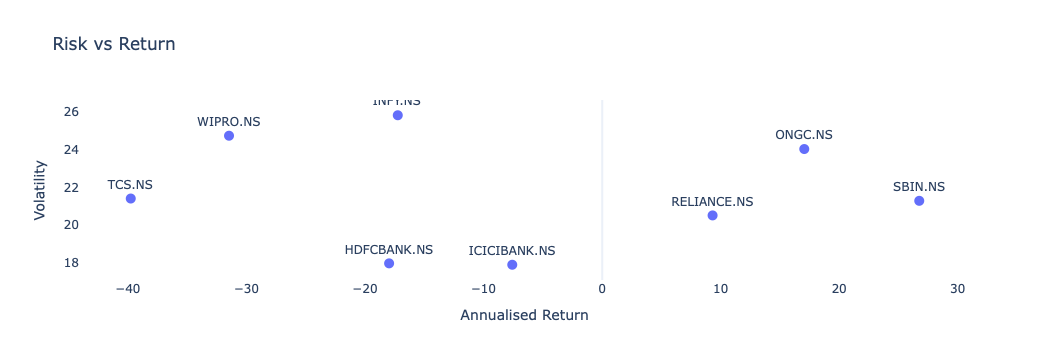

In [14]:
candlestick_with_volume_graph(df, ticker="HDFCBANK.NS")
normalised_prices_graph(df)
risk_return_graph(df)

## Excel Report Export

In [15]:
excel_report(df, stats_df, corr_matrix)

## Key Findings

- IT sector stocks show highest correlation (INFY, TCS, WIPRO)
- Banking stocks exhibit moderate volatility with stable returns
- Energy stocks provide diversification benefits
- High correlation within sectors confirms sector-driven movements
- Risk-return analysis highlights efficient vs inefficient stocks